In [2]:
import yfinance as yf
import pandas as pd
# Function to get stock data
def fetch_stock_data(ticker, start="2020-01-01", end="2024-01-01"):
    stock = yf.download(ticker, start=start, end=end, auto_adjust=True) # Added auto_adjust=True to suppress warning
    stock = stock[['Close']] # Use only closing prices
    return stock
# Fetch example data
df = fetch_stock_data("AAPL")
df.to_csv("All_Stock_Data.csv") # Save for reuse
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           AAPL
Date                 
2020-01-02  72.400505
2020-01-03  71.696625
2020-01-06  72.267944
2020-01-07  71.928070
2020-01-08  73.085106


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load data (changed filename + index handling)
df = pd.read_csv("All_Stock_Data.csv", index_col=0, parse_dates=True, date_format='%Y-%m-%d') # Added date_format to suppress warning

# Use only closing prices
df = df[['Close']]

# Convert to numeric (fix for AAPL/string issue)
df = df.apply(pd.to_numeric, errors='coerce')

# Handle missing values
df.dropna(inplace=True)

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)

# Split into train & test
train_size = int(len(df_scaled) * 0.8)
train_data, test_data = df_scaled[:train_size], df_scaled[train_size:]

# Prepare datasets
X_train, y_train = np.array(range(len(train_data))), train_data.flatten()
X_test, y_test = np.array(range(len(train_data), len(df_scaled))), test_data.flatten()

In [4]:
from sklearn.linear_model import LinearRegression

# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train.reshape(-1, 1), y_train)

# Make Predictions
lr_predictions = lr_model.predict(X_test.reshape(-1, 1))
lr_predictions = scaler.inverse_transform(lr_predictions.reshape(-1, 1))

# Evaluate
from sklearn.metrics import mean_squared_error

lr_mse = mean_squared_error(
    scaler.inverse_transform(test_data),
    lr_predictions
)

print(f"Linear Regression MSE: {lr_mse}")

Linear Regression MSE: 82.42058620224962


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input # Import Input layer

# Function to prepare time-series dataset
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Prepare LSTM Data
seq_length = 10
X_train_lstm, y_train_lstm = create_sequences(train_data, seq_length)
X_test_lstm, y_test_lstm = create_sequences(test_data, seq_length)

# 🔥 FIX: reshape y also (important for stability)
y_train_lstm = y_train_lstm.reshape(-1, 1)
y_test_lstm = y_test_lstm.reshape(-1, 1)

# Reshape for LSTM
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

# Build LSTM Model
lstm_model = Sequential([
    Input(shape=(seq_length, 1)), # Added Input layer to suppress warning
    LSTM(50, return_sequences=True),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

# Compile & Train
lstm_model.compile(optimizer="adam", loss="mean_squared_error")
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=16, verbose=1)

# Make Predictions
lstm_predictions = lstm_model.predict(X_test_lstm)
lstm_predictions = scaler.inverse_transform(lstm_predictions)

# Evaluate
lstm_mse = mean_squared_error(
    scaler.inverse_transform(y_test_lstm),
    lstm_predictions
)

print(f"LSTM MSE: {lstm_mse}")

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0310
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0018
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013
Epoch 13/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012
Epoch 14/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012
Epoch 15/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013
Epoc

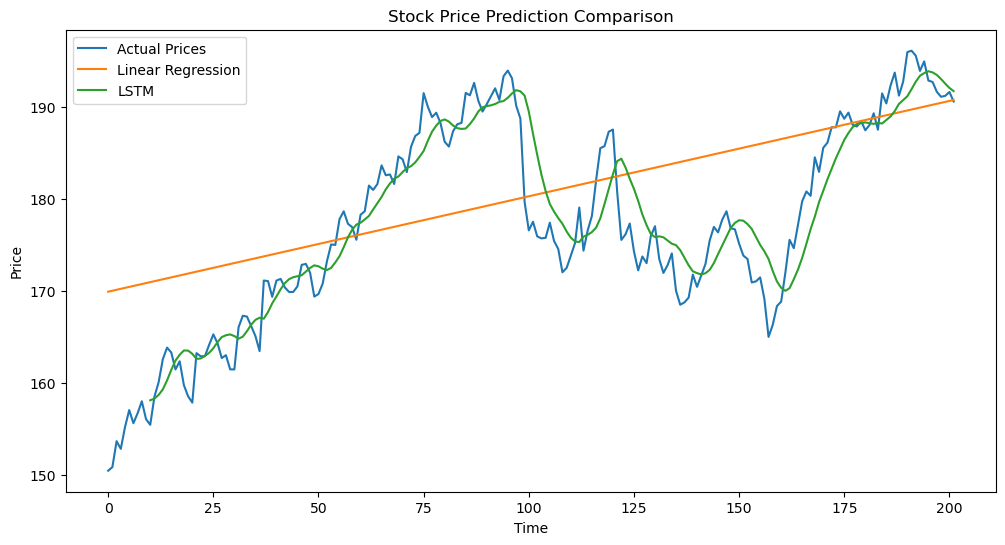

In [6]:
import matplotlib.pyplot as plt

# Actual values
actual_prices = scaler.inverse_transform(test_data)

# Adjust LSTM for plotting
lstm_plot = np.empty_like(actual_prices)
lstm_plot[:] = np.nan
lstm_plot[10:len(lstm_predictions)+10] = lstm_predictions

# Plot
plt.figure(figsize=(12,6))

plt.plot(actual_prices, label="Actual Prices")
plt.plot(lr_predictions, label="Linear Regression")
plt.plot(lstm_plot, label="LSTM")

plt.title("Stock Price Prediction Comparison")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()